In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from matplotlib import cm

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

gpu = torch.device("cuda:0")
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3060


In [3]:
## Constants
num_neurons = 2000
num_i = int(0.1 * num_neurons)
num_e = int(0.9 * num_neurons)
num_channel_inputs = 100
P = 16
k = 100
novel_inds = torch.arange(0, P // 2)
familiar_inds = torch.arange(P // 2, P)
ie_post = (num_e, num_neurons)
ie_pre = (0, num_e)
ei_post = (0, num_e)
ei_pre = (num_e, num_neurons)
w_ie = 0.5
w_ei = -0.2
mult = 100
# Changed when we re-trained
epochs_inner = 2000
eps = 1e-8
snapshot_every = 100

In [4]:
## Util functions
def get_update_inds(post, pre, W):
    weights_slice = W[post[0]:post[1], pre[0]:pre[1]]
    inds = torch.nonzero(weights_slice, as_tuple=True)
    update_inds = (inds[0] + post[0], inds[1] + pre[0])
    
    return update_inds

def odor_corrs(R, family_inds):
    R_adjusted = R[:num_e, family_inds] - torch.mean(R[:num_e, family_inds], dim=1, keepdim=True)
    R_adjusted.t_()
    sigma_E = torch.corrcoef(R_adjusted) -  torch.eye(P // 2, device=gpu)

    avg_corr = torch.mean(torch.abs(sigma_E))

    return avg_corr, sigma_E

# Sparsity per odor, across all (E) neurons
def sparsity_per_odor(R):
    # Epsilon for if we have zero responses
    eps = 1e-6
    sp_per_odor = 1 - ((torch.sum(R[:num_e], dim=0) ** 2 + eps) / (num_e * (torch.sum(R[:num_e] ** 2, dim=0)) + eps))
    # Sparsity nan means that the responses were all 0 for an odor, meaning that its max sparsity of 1
    return sp_per_odor

# Sparsity per (E) neuron, across a given odor family
def sparsity_per_neuron(R, odor_inds):
    sp_per_neuron = 1 - (
                (torch.sum(R[:num_e, odor_inds], dim=1) ** 2) / ((P // 2) * torch.sum(R[:num_e, odor_inds] ** 2, dim=1)))
    return sp_per_neuron

In [5]:
# Takes in mitral activity I and feedforward weights W_ff and computes feedforward activity h_bar_ff
def compute_feedforward_activity(W_ff, I):
    with torch.device(gpu):
        h_ff = (W_ff @ I) * (1 / np.sqrt(num_channel_inputs))
        h_bar_ff = torch.zeros_like(h_ff)
        # Subtract by mean across (excitatory) neurons for each odor
        h_bar_ff[:num_e] = h_ff[:num_e] - torch.mean(h_ff[:num_e], dim=0, keepdim=True)
    return h_bar_ff

# Computes activation threshold for neurons, right now set it at 0
def compute_threshold():
    threshold = torch.zeros((num_neurons, P), device=gpu)
    # Since inhibitory neurons are linear
    threshold[num_e:, :] = 0
    return threshold

# ReLU for excitatory, linear for inhibitory
def neuron_activations(X):
    # Mask to keep excitatory
    mask1 = torch.ones((num_neurons, 1), device=gpu)
    mask1[num_e:, :] = 0
    # Mask to keep inhibitory
    mask2 = torch.zeros((num_neurons, 1), device=gpu)
    mask2[num_e:, :] = 1
    return (torch.relu(X) * mask1) + (X * mask2)

# Computes R for each odor, with the activation threshold theta
def compute_piriform_response(h_bar_ff, W_rec):
    # The coefficient of x_bar
    tau = 1
    # time step
    dt = 0.1
    # Number of time steps
    T = 200
    
    # Initial condition where states are gaussian
    mu_0 = 0.
    sigma_0 = 0.2
    X_0 = torch.normal(mu_0, sigma_0, size=(num_neurons, P))
    X = X_0.to(gpu)
    
    pts = []
    for i in range(T-2):
        with torch.no_grad():
            part1 = -1 * X
            part2 = (W_rec @ neuron_activations(X)) * (1 / np.sqrt(k))
            part3 = h_bar_ff
            dXdt = (1 / tau) * (part1 + part2 + part3)
            X = X + (dXdt * dt)
        # Look at convergence pattern for first odor, assuming that it'll
        # be similar across odors (since they are all independent)
        #pts.append(torch.mean(dXdt, dim=0)[0].item())
   
    # On the last 2 iterations only, track the gradient
    X.requires_grad_(True)
    
    for j in range(2):
        part1 = -1 * X
        part2 = (W_rec @ neuron_activations(X)) * (1 / np.sqrt(k))
        part3 = h_bar_ff
        dXdt = (1 / tau) * (part1 + part2 + part3)
        X = X + (dXdt * dt)
    
    # The total input to the neuron at this last time step (should be equivalent to the resulting value of X after this time step, since dxdt = 0 after the recurrent network converges)
    #total_input = part2 + part3
    threshold = compute_threshold()
    
    # Plot derivatives to see if state converged
    # plt.plot(torch.arange(T-2), pts)
    # plt.show()
    R = neuron_activations(X - threshold)
    
    return R

In [6]:
def compute_update(A, W_rec, R, update_inds, degree, numvars):
    numterms = (degree + 1) ** numvars

    #W_start = W_rec[update_inds].unsqueeze(0).t()
    R_postsyn = R[update_inds[0], :][:, familiar_inds]
    R_presyn = R[update_inds[1], :][:, familiar_inds]

    post = R_postsyn[update_inds[0], :]
    pre = R_presyn[update_inds[1], :]
    # For now no W
    #ws = torch.repeat_interleave(W_rec[update_inds[0], update_inds[1]].unsqueeze(1), repeats=P, dim=1)
    post = post.expand(numterms, -1, -1)
    pre = pre.expand(numterms, -1, -1)
    #ws = torch.repeat_interleave(ws.unsqueeze(0), repeats=numterms, dim=0)
    #ws = ws.expand(numterms, -1, -1)
    #combined = torch.stack((post, pre, ws), dim=1)
    combined = torch.stack((post, pre), dim=1)
    print(combined.shape)
    exps = torch.cartesian_prod(*([torch.arange(degree + 1)] * numvars)).to(gpu)
    #exps = exps.unsqueeze(2).unsqueeze(3)
    exps = exps.broadcast_to(combined.shape)
    result = torch.pow(combined, exps)
    sum_terms = torch.prod(result, dim=1)
    A_coef = A.unsqueeze(1).unsqueeze(2)
    result = A_coef * sum_terms
    updates_per_odor = torch.sum(result, dim=0)
    updates = torch.mean(updates_per_odor, dim=1)

    return updates

In [87]:
# Subdivides loss and returns in 2D tensor of (num_intervals, 2) where the second dim gives (epoch_start, epoch_end)
def load_loss(num_intervals, epoch_bound, real, type):
    if epoch_bound == None:
        epoch_bound = (0, epochs_inner)
    dir = f"../training_scripts/checkpt_train/{type}"
    datapath = f"{dir}/realization_{real}/data"
    corrs = torch.load(f"{datapath}/corrs.pt").detach().cpu()
    corr_region = corrs[epoch_bound[0]: epoch_bound[1]]
    total_reduction = corr_region[-1] - corr_region[0]
    interval = total_reduction / (num_intervals + 1)
    loss_values = corr_region[0] + torch.arange(num_intervals + 1) * interval
    sorted, orig_indices = torch.sort(corr_region)
    inds = torch.bucketize(loss_values, sorted)
    inds = orig_indices[inds]
    epoch_intervals = []
    for i in range(1, num_intervals+1):
        # Round to nearest 100 epochs b/c those are the snapshots we covered
        lower_bound = round(inds[i-1].item() / float(snapshot_every)) * snapshot_every
        upper_bound = round(inds[i].item() / float(snapshot_every)) * snapshot_every
        loss_bounds = (lower_bound, upper_bound)
        epoch_intervals.append(loss_bounds)
    
    return epoch_intervals

# Alpha: how much to weight the regularization (lower for E->I b/c we have less training samples)
def fit_weights(X, Y):
    # L1 ratio - 0.02 is all L2, 1 is all L1
    #reg = ElasticNet(l1_ratio=0.02)
    #reg = RidgeCV(alphas=torch.arange(1, 11) * 0.05)
    #reg = ElasticNet(alpha=alpha, l1_ratio=1.0)
    
    # Already have intercept from power series transform
    reg = LinearRegression(fit_intercept=False)
    reg.fit(X, Y)

    return reg

In [85]:
def prepare_input(post, pre, r, num_intervals=5, use_weights=True, epoch_subset=None, train_subset=None):
    degree = 2
    
    # Override use_weights if we have more than 1 interval
    if num_intervals > 1:
        use_weights = True
    
    if post == (num_e, num_neurons):
        type = "ie"
    else:
        type = "ei"

    type = "ie" if (post[1] == num_neurons) else "ei"
    loss_intervals = load_loss(num_intervals, epoch_subset, r, type)

    interval_samples = []
    interval_labels = []
    for i in range(num_intervals):
        epoch_start, epoch_end = loss_intervals[i]

        dir = f"../training_scripts/checkpt_train/{type}"
        datapath = f"{dir}/realization_{r}/data/snapshots"
        W0 = torch.load(f"{datapath}/epoch_{epoch_start}/W_trained.pt").detach().cpu()
        Wf = torch.load(f"{datapath}/epoch_{epoch_end-100}/W_trained.pt").detach().cpu()
        R_epoch = epoch_start
        R = torch.load(f"{datapath}/epoch_{R_epoch}/R_trained.pt").detach().cpu()

        update_inds = get_update_inds(post, pre, W0)
        delta_W = Wf[update_inds] - W0[update_inds]

        # Train on all weights
        if train_subset == None:
            train_subset = (torch.min(delta_W), torch.max(delta_W))

        # Train subset: the subset of weights that we fit on
        train_inds = torch.logical_and(delta_W >= train_subset[0], delta_W <= train_subset[1])
        update_inds = (update_inds[0][train_inds], update_inds[1][train_inds])
        delta_W = delta_W[train_inds]

        # Num vars in polynomial (presyn, postsyn, weight)
        numvars = 3 if use_weights else 2
        # Num terms in polynomial is (degree + 1) ** num_vars
        numterms = (degree + 1) ** numvars


        post = R[update_inds[0], :][:, familiar_inds]
        pre = R[update_inds[1], :][:, familiar_inds]

        if use_weights:
            ws = W0[update_inds[0], update_inds[1]].unsqueeze(1).expand((-1, P // 2))
            features = torch.stack((post, pre, ws), dim=1)
        else:
            features = torch.stack((post, pre), dim=1)
        
        features = features.unsqueeze(1).expand((-1, numterms, -1, -1))

        features_mu = torch.mean(features, dim=0, keepdim=True)
        features_std = torch.std(features, dim=0, keepdim=True)
        normed_features = (features - features_mu) / (features_std + eps)

        exps = torch.cartesian_prod(*([torch.arange(degree + 1)] * numvars))
        print(exps)
        exps = exps.unsqueeze(0).unsqueeze(3).broadcast_to(normed_features.shape)

        transformed_features = torch.pow(normed_features, exps).prod(dim=2, keepdim=False)
        transformed_features = transformed_features.mean(dim=-1)
        interval_samples.append(transformed_features)
        interval_labels.append(delta_W)

    all_samples = torch.cat(interval_samples, dim=0)
    all_labels = torch.cat(interval_labels, dim=0)

    # Z-scoring - we don't do that for now
    # Y_mu = torch.mean(delta_W, dim=0, keepdim=True)
    # Y_std = torch.std(delta_W, dim=0, keepdim=True)
    # normed_Y = (delta_W - Y_mu) / (Y_std + eps)

    return all_samples, all_labels

In [88]:
def predicted_responses(coef, intercept, X, r, odor_inds, epoch_start, epoch_end, use_weights=False):
    if post == (num_e, num_neurons):
        type = "ie"
    else:
        type = "ei"

    #X, _, update_inds = prepare_input(post, pre, r, epoch_start, epoch_end, use_weights=use_weights, train_subset=None)

    dir = f"../training_scripts/checkpt_train/{type}"
    datapath = f"{dir}/realization_{r}/data/snapshots"
    I = torch.load(f"{dir}/realization_{r}/data/I.pt").detach()
    W_ff = torch.load(f"{dir}/realization_{r}/data/W_ff.pt").detach()
    hbar_ff = compute_feedforward_activity(W_ff, I)
    W0 = torch.load(f"{datapath}/epoch_{epoch_start}/W_trained.pt").detach()
    Wf = torch.load(f"{datapath}/epoch_{epoch_end-100}/W_trained.pt").detach()
    R0 = torch.load(f"{datapath}/epoch_{epoch_start}/R_trained.pt").detach()
    Rf = torch.load(f"{datapath}/epoch_{epoch_end-100}/R_trained.pt").detach()

    delta_pred = (X @ torch.Tensor(coef)) + intercept
    true_delta = Wf[update_inds] - W0[update_inds]

    W_pred = W0.clone()
    W_pred[update_inds] = W0[update_inds] + delta_pred.to(gpu)
    R_pred = compute_piriform_response(hbar_ff, W_pred.to(gpu))
    

    # TODO put novel and familiar odor corrs next to each other    

    start_corr, _ = odor_corrs(R0, odor_inds)
    start_sp = sparsity_per_odor(R0)
    true_corr, _ = odor_corrs(Rf, odor_inds)
    true_sp = sparsity_per_odor(Rf)
    pred_corr, _ = odor_corrs(R_pred, odor_inds)
    pred_sp = sparsity_per_odor(R_pred)

    return (start_corr.item(), true_corr.item(), pred_corr.item()), (start_sp, true_sp, pred_sp)

In [89]:
def test_corr(post, pre, real):
    num_intervals = 1
    epoch_bound = (0, 10000)
    type = "ie" if (post[1] == num_neurons) else "ei"
    loss_intervals = load_loss(num_intervals, epoch_bound, real, type)

    for i in range(num_intervals):
        epoch_start, epoch_end = loss_intervals[i]
        X, Y, _ = prepare_input(post, pre, real, epoch_start, epoch_end)
        # TODO once single fitting for all samples across loss intervals
        reg = fit_weights(X, Y)
        corr, _ = predicted_responses(reg.coef_, reg.intercept_, post, pre, real, familiar_inds, epoch_start, epoch_end, use_weights=False)
        print(f"Loss interval {i}: ({epoch_start}, {epoch_end}) Start: {corr[0]}, True End: {corr[1]}, Pred End: {corr[2]}")


In [90]:
test_corr(ie_post, ie_pre, 1)
# Need to collate all samples together and run single linear regression

tensor([[0, 0],
        [0, 1],
        [0, 2],
        [1, 0],
        [1, 1],
        [1, 2],
        [2, 0],
        [2, 1],
        [2, 2]])
tensor([[0, 0],
        [0, 1],
        [0, 2],
        [1, 0],
        [1, 1],
        [1, 2],
        [2, 0],
        [2, 1],
        [2, 2]])
Loss interval 0: (0, 1400) Start: 0.26529425382614136, True End: 0.23917530477046967, Pred End: 0.2573237717151642


tensor([[0, 0],
        [0, 1],
        [0, 2],
        [1, 0],
        [1, 1],
        [1, 2],
        [2, 0],
        [2, 1],
        [2, 2]])
[ 0.06264031  0.29844207 -0.03892138  0.00436923  0.01065182 -0.01050192
 -0.02957214 -0.05813072  0.00947115]


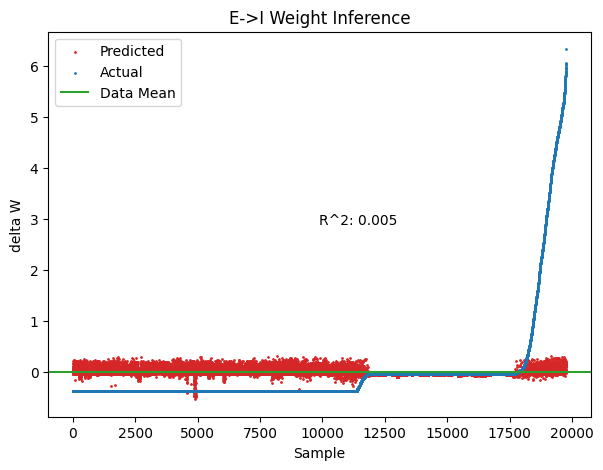

tensor([[0, 0],
        [0, 1],
        [0, 2],
        [1, 0],
        [1, 1],
        [1, 2],
        [2, 0],
        [2, 1],
        [2, 2]])
[-0.03803591  0.02274178 -0.01958754 -1.1444751   0.0708686  -0.05511859
  0.04747421 -0.01521022  0.01008828]


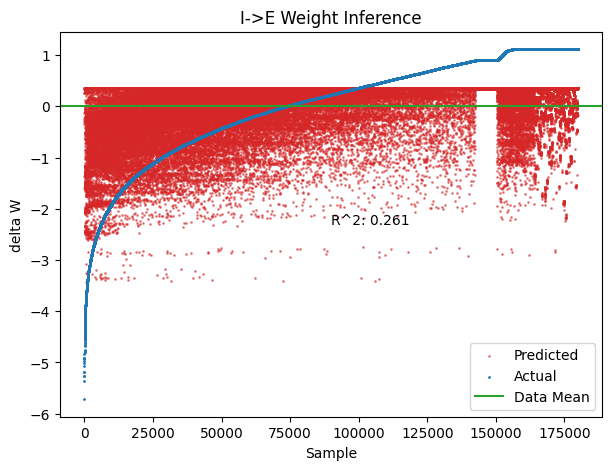

In [91]:
real = 1

#train_subset = (-w_ie, mult*w_ie)
X_ie, Y_ie, _ = prepare_input(ie_post, ie_pre, r=real, epoch_start=0, epoch_end=epochs_inner, train_subset=None)
reg_ie_0 = fit_weights(X_ie, Y_ie)
coords = torch.arange(X_ie.shape[0])
sort_ie, inds_ie = torch.sort(Y_ie)
print(reg_ie_0.coef_)
fig = plt.figure(figsize=(7, 5))
plt.scatter(coords, reg_ie_0.predict(X_ie)[inds_ie], color="tab:red", s=1, label="Predicted")
plt.scatter(coords, sort_ie, color="tab:blue", s=1, label="Actual")
plt.text(0.5, 0.5, f"R^2: {reg_ie_0.score(X_ie, Y_ie):.3f}", transform=fig.get_axes()[0].transAxes)
plt.axhline(torch.mean(Y_ie), color="tab:green", label="Data Mean")
plt.legend()
plt.ylabel("delta W")
plt.xlabel("Sample")
plt.title("E->I Weight Inference")
plt.show()
plt.close(fig)

#Min/max of weight values
#train_subset = (mult*w_ei, -w_ei)
X_ei, Y_ei, _ = prepare_input(ei_post, ei_pre, r=real, epoch_start=0, epoch_end=epochs_inner, train_subset=None)
reg_ei_0 = fit_weights(X_ei, Y_ei)
coords = torch.arange(X_ei.shape[0])

sample_set = 100000
sample = torch.randperm(coords.shape[0])[:sample_set]
sort_ei, inds_ei = torch.sort(Y_ei)
print(reg_ei_0.coef_)
fig = plt.figure(figsize=(7, 5))
plt.scatter(coords[sample], reg_ei_0.predict(X_ei)[inds_ei][sample], color="tab:red", s=1, alpha=0.5, label="Predicted")
plt.scatter(coords[sample], sort_ei[sample], color="tab:blue", s=1, label="Actual")
plt.text(0.5, 0.5, f"R^2: {reg_ei_0.score(X_ei, Y_ei):.3f}", transform=fig.get_axes()[0].transAxes)
plt.axhline(torch.mean(Y_ei), color="tab:green", label="Data Mean")
plt.legend()
plt.ylabel("delta W")
plt.xlabel("Sample")
plt.title("I->E Weight Inference")
plt.show()
plt.close(fig)

In [54]:
def generate_spars_plot(spars):
    num_plots = spars.shape[0]
    start = 0.5
    space = 1
    plot_space = 1.5
    width = space / 2
    spars_coords = torch.Tensor([start, start+space])
    spread = (torch.rand(size=(P // 2,)) - start) * width
    plot_coords = torch.hstack([torch.repeat_interleave(spars_coords[0], repeats=num_plots), torch.repeat_interleave(spars_coords[1], repeats=num_plots)])
    plot_coords[:num_plots] = plot_coords[:num_plots] + (torch.arange(num_plots) * (space + plot_space))
    plot_coords[num_plots:] = plot_coords[num_plots:] + (torch.arange(num_plots) * (space + plot_space))
    spread = torch.repeat_interleave(spread.unsqueeze(0), repeats=num_plots, dim=0)

    plt.scatter(spread + plot_coords[:num_plots].unsqueeze(1), spars[:, novel_inds].detach().cpu(), label="Novel")
    plt.scatter(spread + plot_coords[num_plots:].unsqueeze(1), spars[:, familiar_inds].detach().cpu(), label="Familiar")
    plt.xticks(ticks=plot_coords[:num_plots] + width, labels=["start", "true_end", "full_pred", "no_mu", "no_cov", "no_vars", "no_var_cov"])
    plt.xlim(left=plot_coords[0]-(1.5*width), right=plot_coords[-1]+(1.5*width))
    plt.ylim(0, 1.1)
    plt.bar(plot_coords[:num_plots], torch.mean(spars[:, novel_inds], dim=1).detach().cpu(), width = width, alpha=0.5, color="green")
    plt.bar(plot_coords[num_plots:], torch.mean(spars[:, familiar_inds], dim=1).detach().cpu(), width = width, alpha=0.5, color="green")
    plt.legend(loc="lower left")

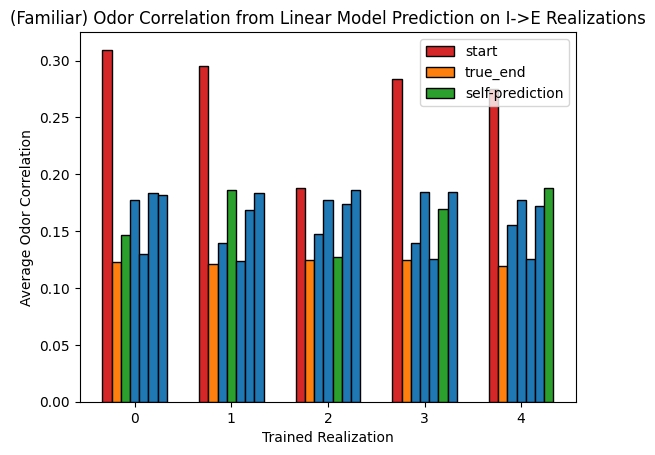

In [55]:
# For I->E, train on single realization and decorrelate
reals = [i for i in range(5)]
# Width of bars
width = 0.2
# Offset between groups of bars
offset = 0.5 * width
num_bars = len(reals) + 2
x = torch.arange(len(reals)) * num_bars * (width + offset)
for i in reals:
    X_fit, Y_fit, _ = prepare_input(ei_post, ei_pre, r=i, epoch_start=0, epoch_end=epochs_inner, train_subset=None)
    reg = fit_weights(X_fit, Y_fit)
    corrs = []
    for r in reals:
        corr, _ = predicted_responses(reg.coef_, reg.intercept_, ei_post, ei_pre, r, familiar_inds, epoch_start=0, epoch_end=epochs_inner)
        if r == i:
            prev_corrs = corrs
            corrs = list(corr[:2])
            corrs.extend(prev_corrs)
        
        corrs.append(corr[2])

    colors = ["tab:blue"] * num_bars
    colors[0] = "tab:red"
    colors[1] = "tab:orange"
    colors[num_bars-len(reals)+i] = "tab:green"

    if i == len(reals) - 1:
        labels = [""] * num_bars
        labels[0] = "start"
        labels[1] = "true_end"
        labels[num_bars-len(reals)+i] = "self-prediction"
    else:
        labels = [None] * 7

    plt.bar(x[i] + torch.arange(num_bars) * width, corrs, width=width, edgecolor="black", color=colors, label=labels)

plt.xticks(x + (num_bars // 2 * width), labels=reals)
plt.legend()
plt.title("(Familiar) Odor Correlation from Linear Model Prediction on I->E Realizations")
plt.xlabel("Trained Realization")
plt.ylabel("Average Odor Correlation")
plt.show()

In [36]:
# corrs, sp_ = predicted_responses(reg_ei_only_E.coef_, reg_ei_only_E.intercept_, ei_post, ei_pre, real, familiar_inds, epoch_start=0, epoch_end=epochs_inner, regime="only_E")
# fig = plt.figure(figsize=(9, 4))
# bc1 = plt.bar(torch.arange(len(corrs)), corrs, tick_label=["start", "true_end", "pred"])
# plt.bar_label(bc1, fmt="%.3f")

new_coef = np.copy(reg_ei_0.coef_)
new_coef[[0, 1, 3, 4, 5]] = 0
corrs, spars = predicted_responses(new_coef, reg_ei_0.intercept_, ei_post, ei_pre, 3, familiar_inds, epoch_start=0, epoch_end=epochs_inner)
fig = plt.figure(figsize=(9, 4))
bc1 = plt.bar(torch.arange(len(corrs)), corrs, tick_label=["start", "true_end", "pred"])
plt.bar_label(bc1, fmt="%.3f")
plt.show()

fig = plt.figure(figsize=(8, 3))
bc1 = plt.bar(torch.arange(len(spars)), spars, tick_label=["start", "true_end", "full_pred"])
plt.bar_label(bc1, fmt="%.3f")
plt.show()

# TODO make sparsity work
# Y_hat, Y = pred_weights(new_coef, reg_ei_0.intercept_, ei_post, ei_pre, 3, epoch_start=0, epoch_end=epochs_inner, regime="normal")
# coords = torch.arange(Y_hat.shape[0])
# sort, inds = torch.sort(Y)
# fig = plt.figure(figsize=(7, 5))
# plt.scatter(coords, Y_hat[inds], color="tab:red", s=1, label="Predicted")
# plt.scatter(coords, sort, color="tab:blue", s=1, label="Actual")
# plt.show()
# plt.close(fig)

# When we train I->E on full set of features but then predict with only the postsynaptic (E) mean, we decorrelate well
# However, when we train using only postsynaptic mean/var as features, we don't decorrelate well (maybe more features can account for noise?)
# Excitatory neruons which have mean response 0 won't propagate loss through them, so their weights won't change (and the change is just given by the intercept)

# Two cases by which a neuron could have high mean across odors:
# 1. it responds uniformly to a lot of odors (and thereby has low variance)
# 2. it responds selectively to some odors but very strongly to those (and thereby has a high variance)
# In the feature weighting, since the mean was very high, if case 2 was true then it would still be able to decorrelate by inhibiting neurons with high variance
# However, this isn't the case since when we took out the mean we stopped being able to decorrelate
# Thus, hypothesis is that we have selective inhibition for neurons which respond to lots of odors, thereby decorrelating the response between any pair of odors
# This inhibition doesn't have to push the neuron below its activation threshold and thus population sparsity doesn't have to change


TypeError: predicted_responses() got an unexpected keyword argument 'only_E'